In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data/student.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
print("Categories in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" ")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [12]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numerical features: {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features: {}".format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = (df['total_score'] / 3).round(2)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [84]:
subjects = ['math_score', 'reading_score', 'writing_score']

In [85]:
for subject in subjects:
    full_marks_count = df[df[subject] == 100]['average_score'].count()
    print(f"Number of students with full marks in {subject.replace('_score','').capitalize()}: {full_marks_count}")

Number of students with full marks in Math: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


In [86]:
for subject in subjects:
    low_score_count = df[df[subject] <= 20]['average_score'].count()
    print(f"Number of students with less than 20 marks in {subject.replace('_score','').capitalize()}: {low_score_count}")

Number of students with less than 20 marks in Math: 4
Number of students with less than 20 marks in Reading: 1
Number of students with less than 20 marks in Writing: 3


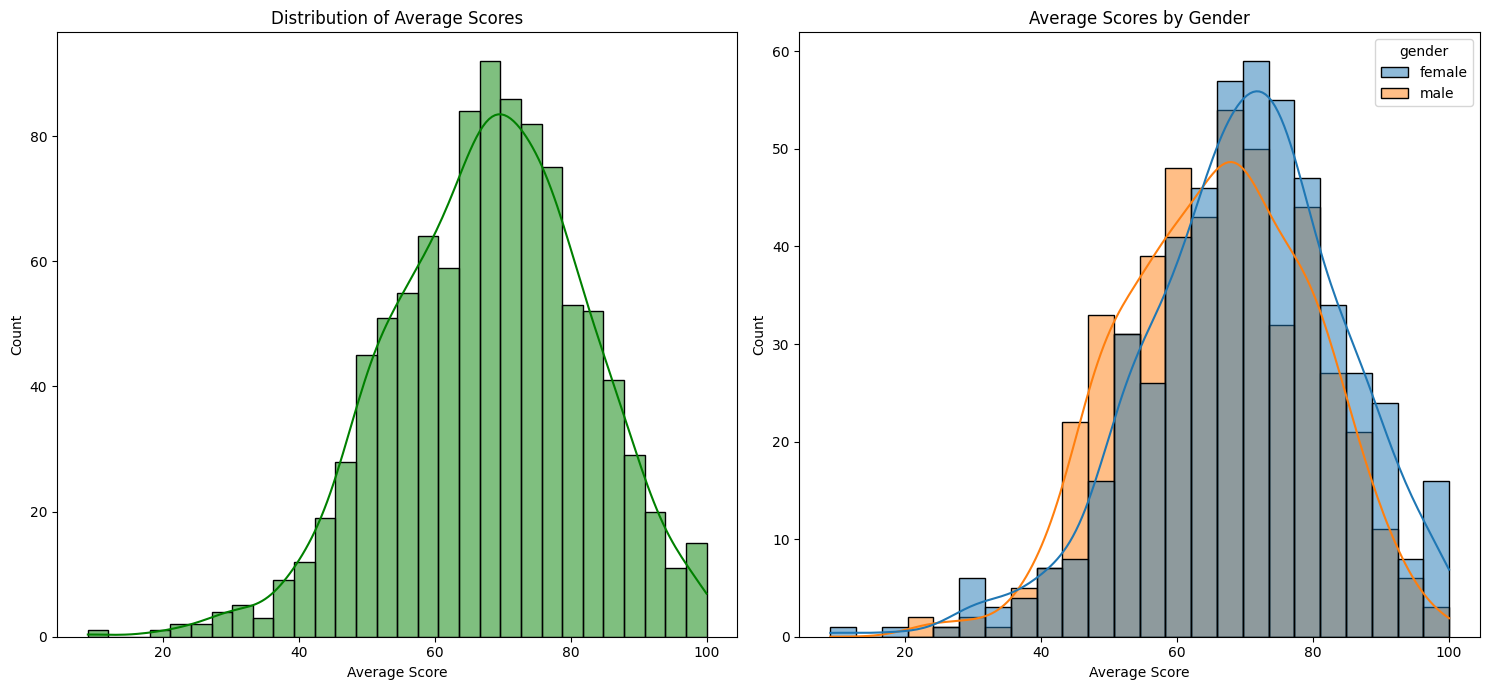

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g', ax=axs[0])
axs[0].set_title('Distribution of Average Scores')
axs[0].set_xlabel('Average Score')
axs[0].set_ylabel('Count')

sns.histplot(data=df, x='average_score', kde=True, hue='gender', ax=axs[1])
axs[1].set_title('Average Scores by Gender')
axs[1].set_xlabel('Average Score')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

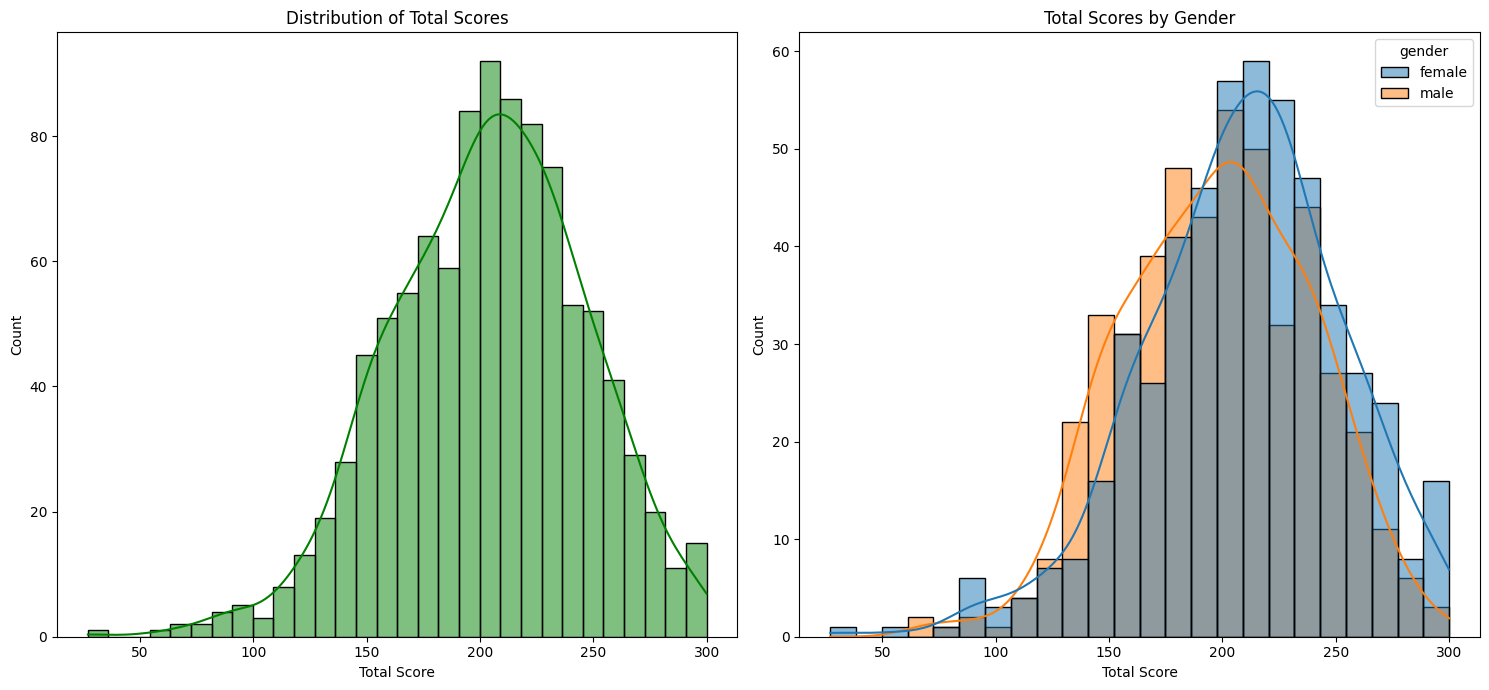

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

sns.histplot(data=df, x='total_score', bins=30, kde=True, color='g', ax=axs[0])
axs[0].set_title('Distribution of Total Scores')
axs[0].set_xlabel('Total Score')
axs[0].set_ylabel('Count')

sns.histplot(data=df, x='total_score', kde=True, hue='gender', ax=axs[1])
axs[1].set_title('Total Scores by Gender')
axs[1].set_xlabel('Total Score')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

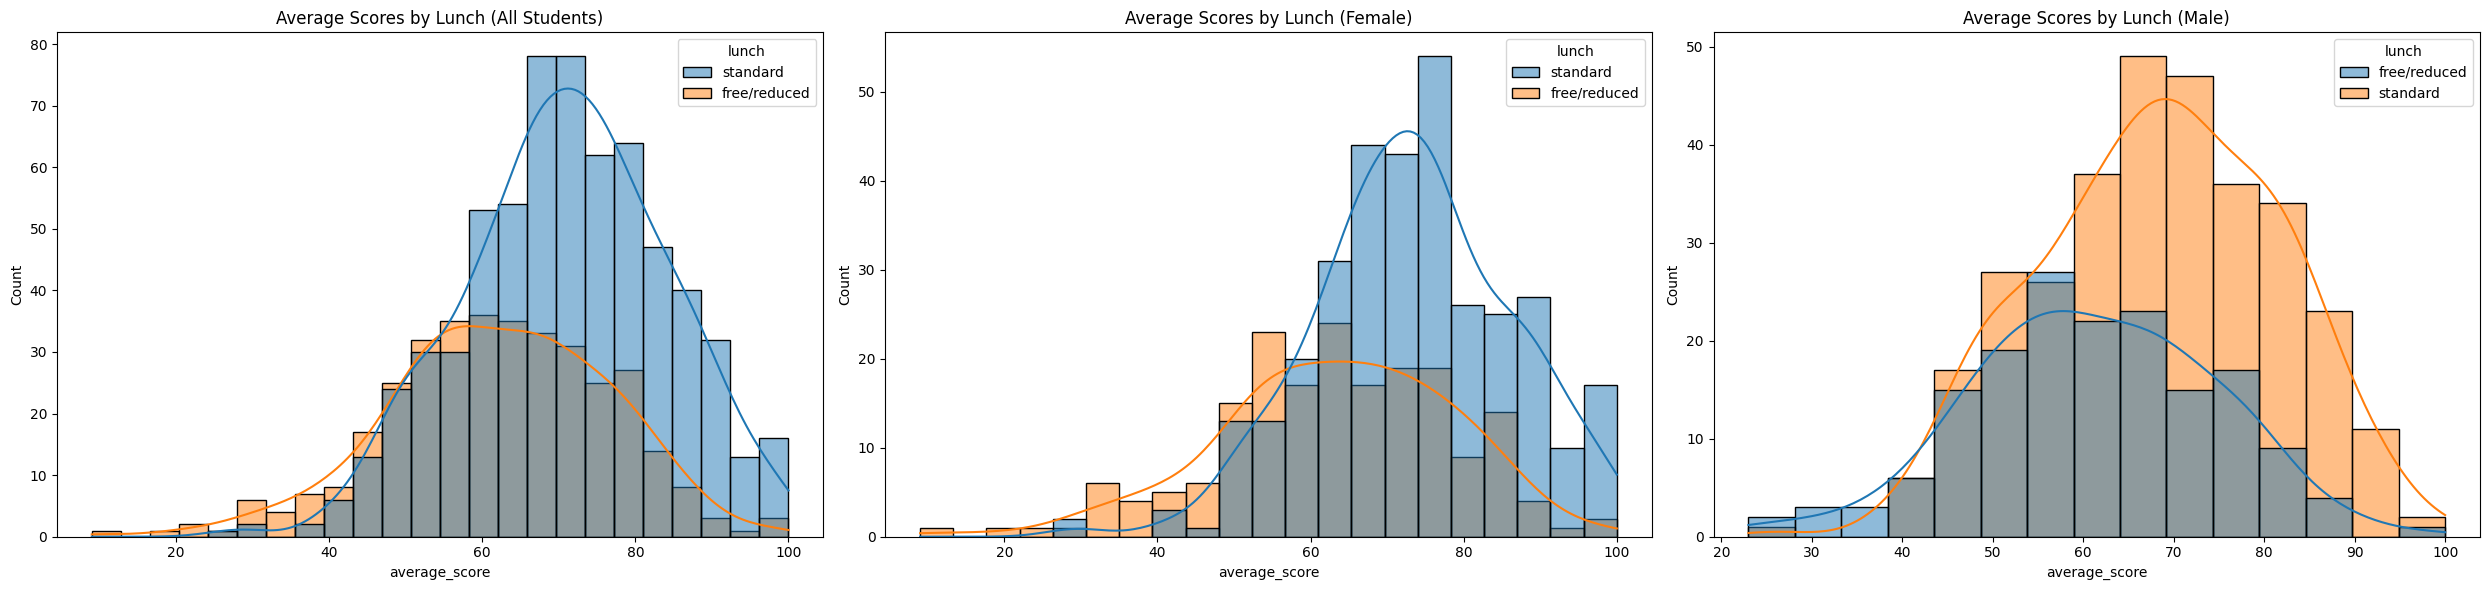

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average_score', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title('Average Scores by Lunch (All Students)')

sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title('Average Scores by Lunch (Female)')

sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='lunch', ax=axs[2])
axs[2].set_title('Average Scores by Lunch (Male)')

plt.tight_layout()
plt.show()

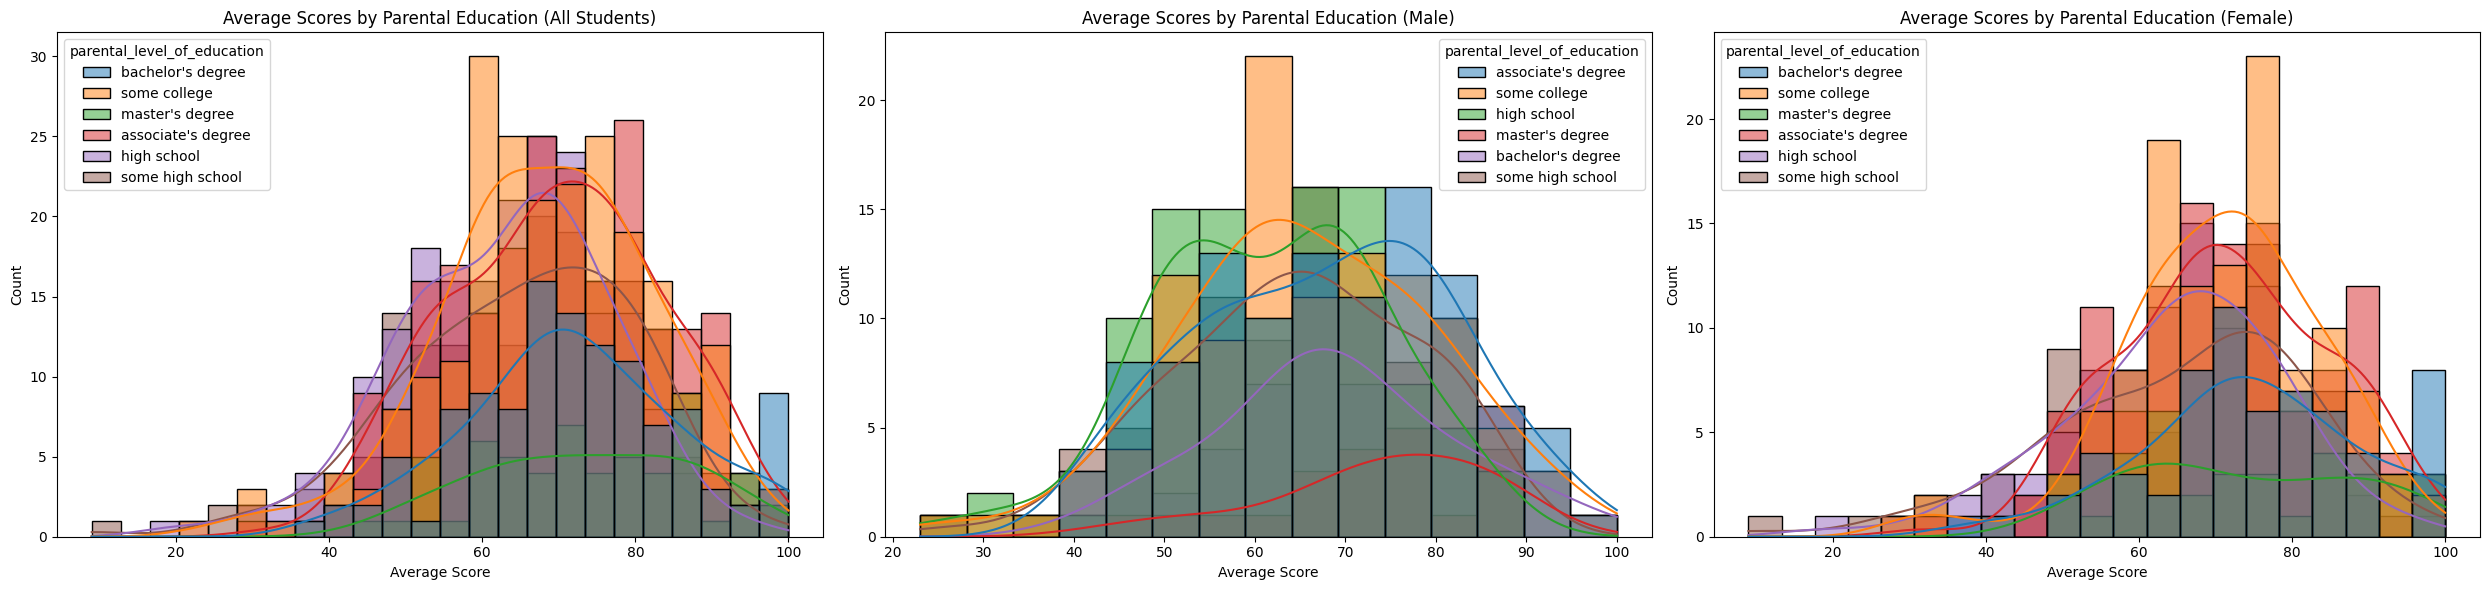

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average_score', kde=True, hue='parental_level_of_education', ax=axs[0])
axs[0].set_title('Average Scores by Parental Education (All Students)')
axs[0].set_xlabel('Average Score')
axs[0].set_ylabel('Count')

sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='parental_level_of_education', ax=axs[1])
axs[1].set_title('Average Scores by Parental Education (Male)')
axs[1].set_xlabel('Average Score')
axs[1].set_ylabel('Count')

sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='parental_level_of_education', ax=axs[2])
axs[2].set_title('Average Scores by Parental Education (Female)')
axs[2].set_xlabel('Average Score')
axs[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

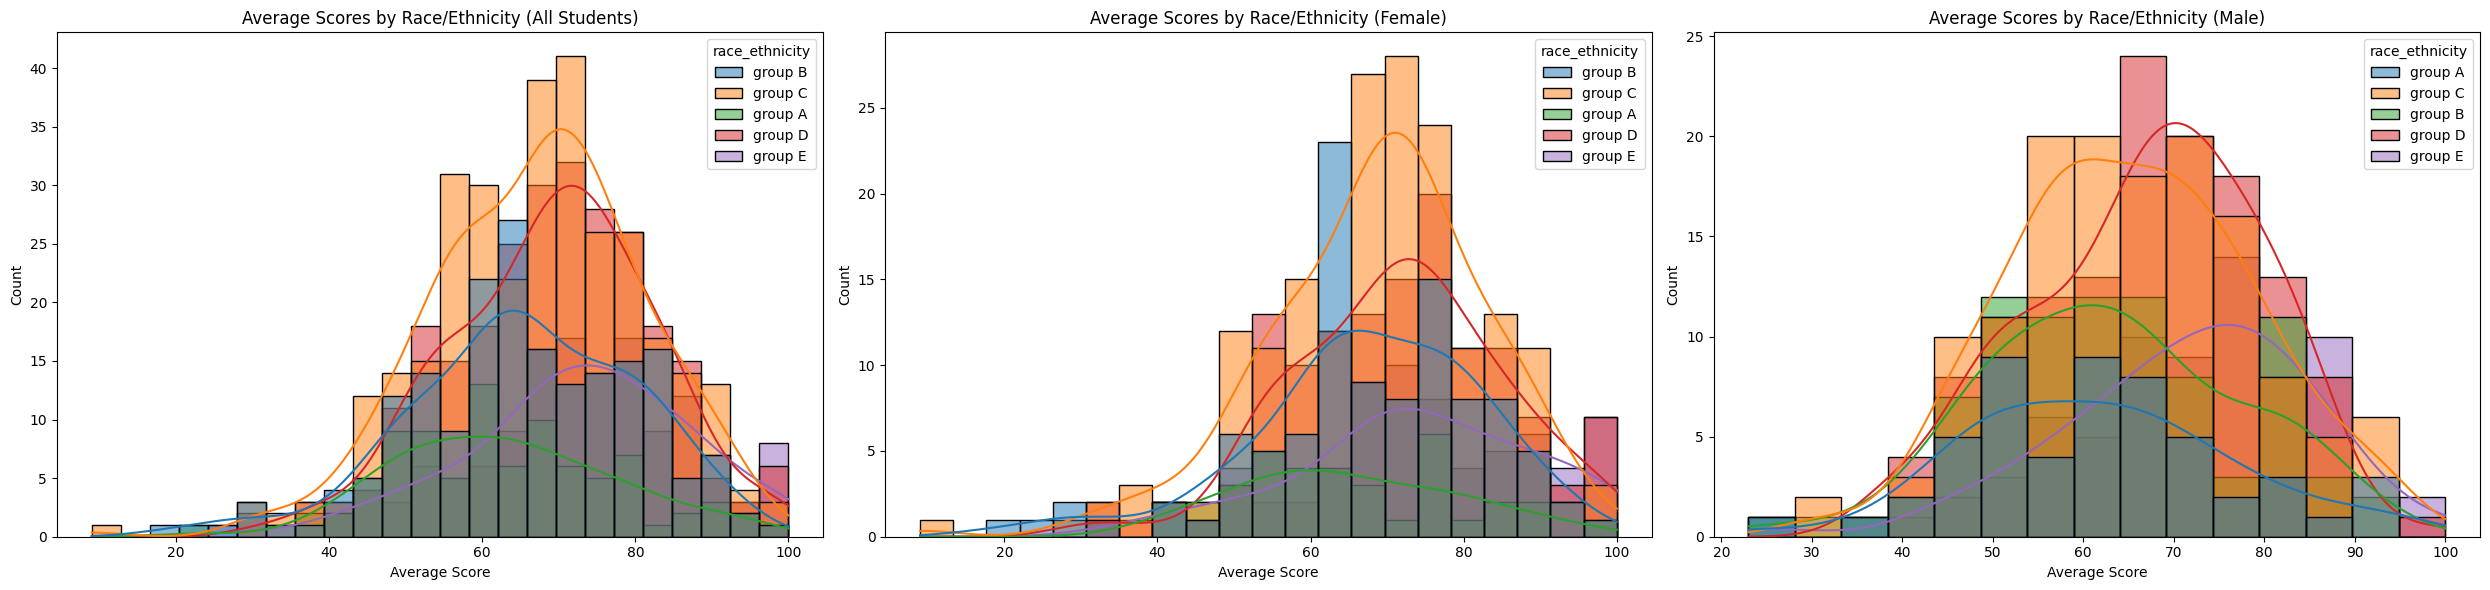

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average_score', kde=True, hue='race_ethnicity', ax=axs[0])
axs[0].set_title('Average Scores by Race/Ethnicity (All Students)')
axs[0].set_xlabel('Average Score')
axs[0].set_ylabel('Count')

sns.histplot(data=df[df.gender=='female'], x='average_score', kde=True, hue='race_ethnicity', ax=axs[1])
axs[1].set_title('Average Scores by Race/Ethnicity (Female)')
axs[1].set_xlabel('Average Score')
axs[1].set_ylabel('Count')

sns.histplot(data=df[df.gender=='male'], x='average_score', kde=True, hue='race_ethnicity', ax=axs[2])
axs[2].set_title('Average Scores by Race/Ethnicity (Male)')
axs[2].set_xlabel('Average Score')
axs[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

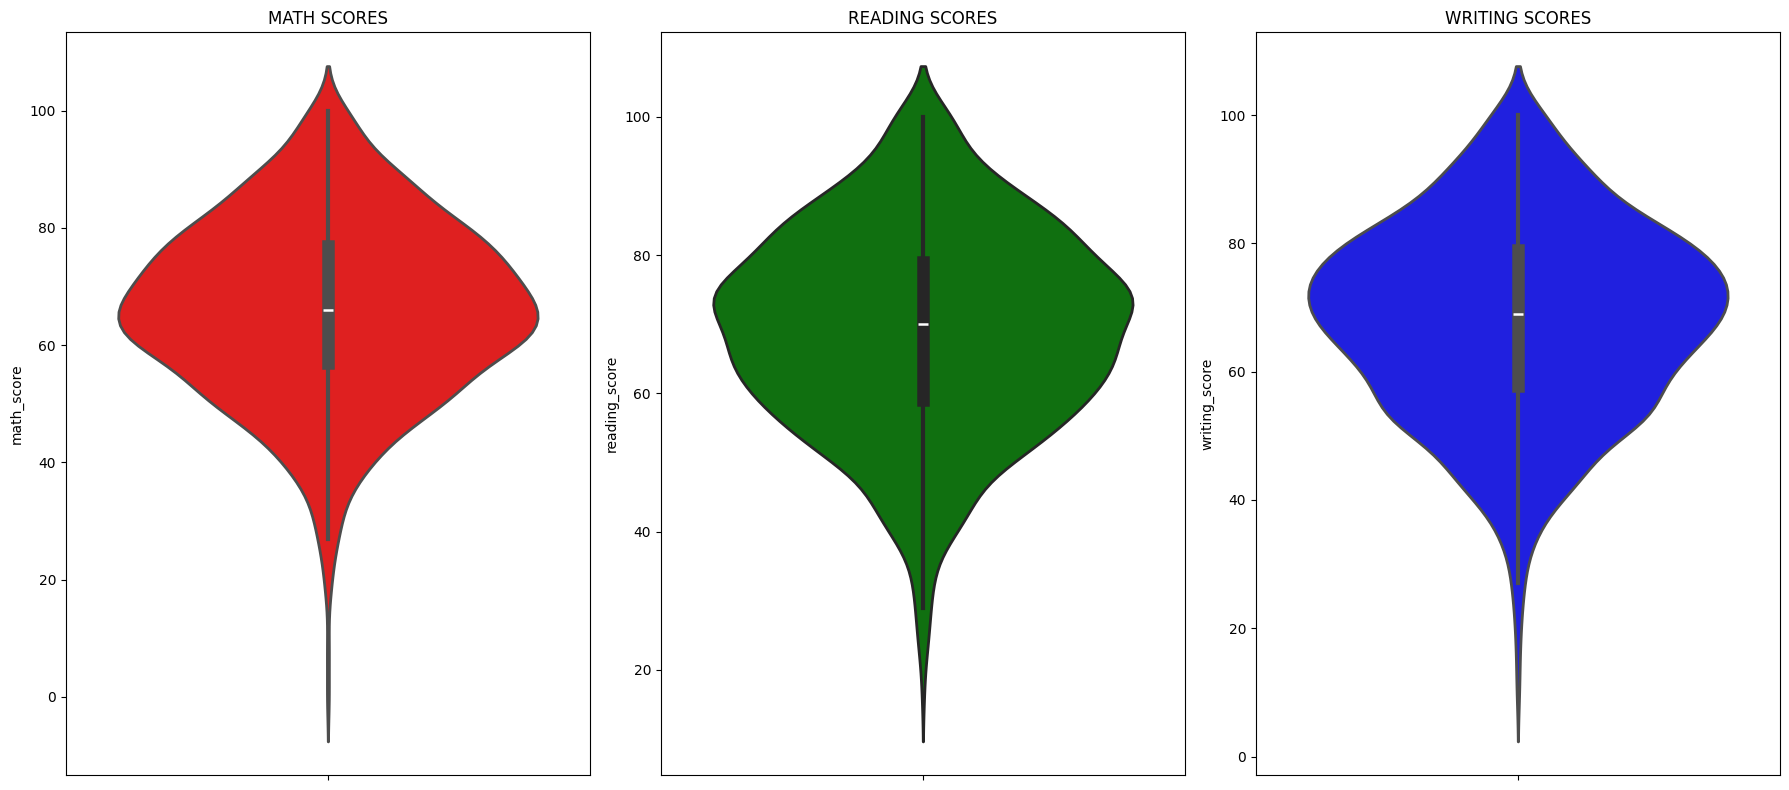

In [40]:
plt.figure(figsize=(18,8))

plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score', data=df, color='red', linewidth=2)

plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=2)

plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=2)

plt.tight_layout()
plt.show()

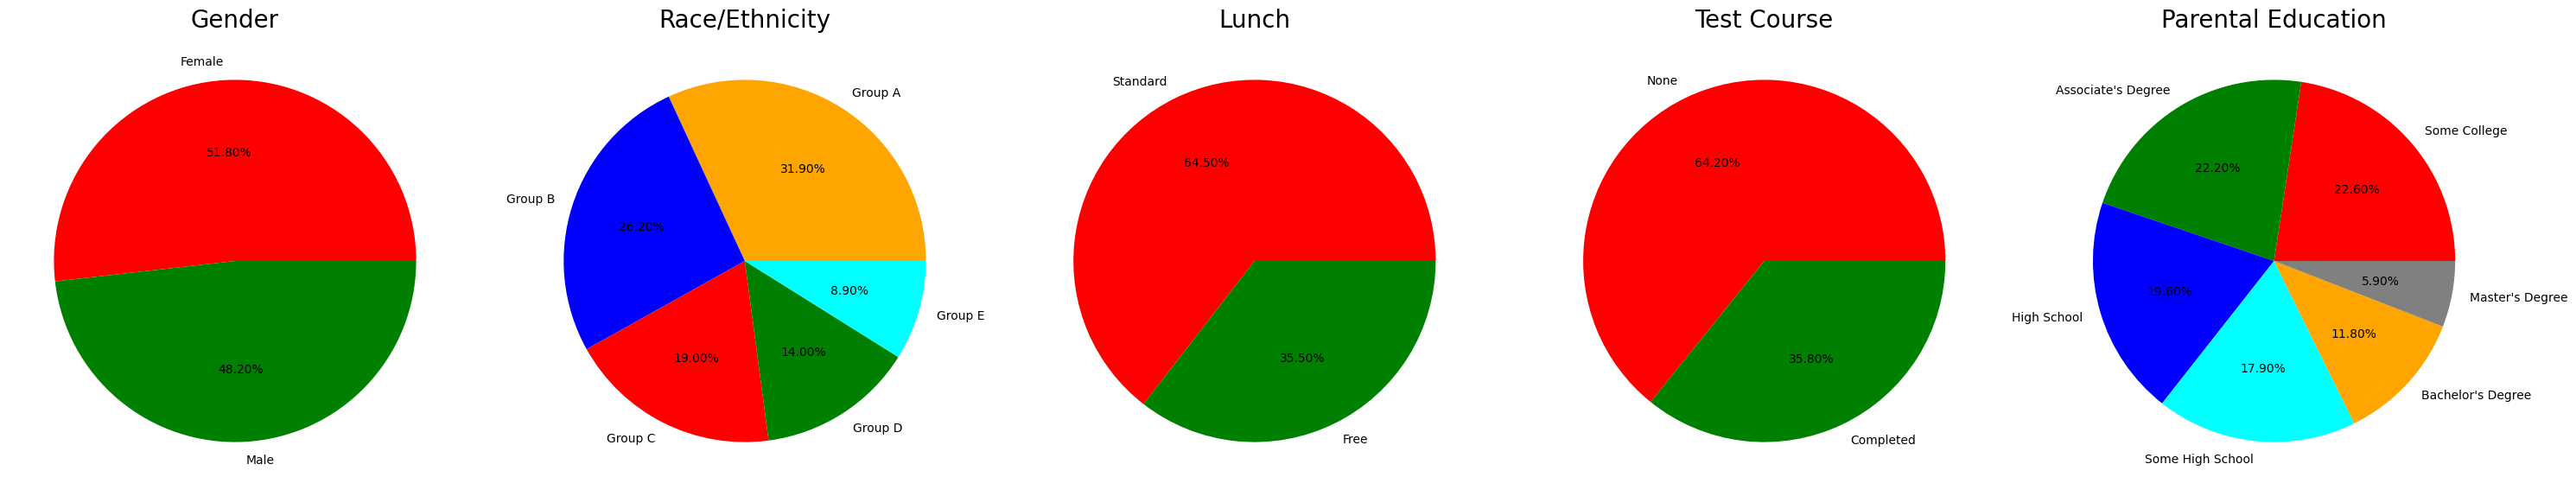

In [41]:
plt.rcParams['figure.figsize'] = (30, 12)

charts = [
    ('gender', ['Female', 'Male'], ['red','green'], 'Gender'),
    ('race_ethnicity', ['Group A','Group B','Group C','Group D','Group E'], 
     ['orange','blue','red','green','cyan'], 'Race/Ethnicity'),
    ('lunch', ['Standard','Free'], ['red','green'], 'Lunch'),
    ('test_preparation_course', ['None','Completed'], ['red','green'], 'Test Course'),
    ('parental_level_of_education', 
     ['Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"],
     ['red','green','blue','cyan','orange','grey'], 'Parental Education')
]

for i, (col, labels, colors, title) in enumerate(charts, 1):
    plt.subplot(1, 5, i)
    sizes = df[col].value_counts()
    plt.pie(sizes, labels=labels, colors=colors, autopct='%.2f%%')
    plt.title(title, fontsize=20)
    plt.axis('off')

plt.tight_layout()
plt.show()

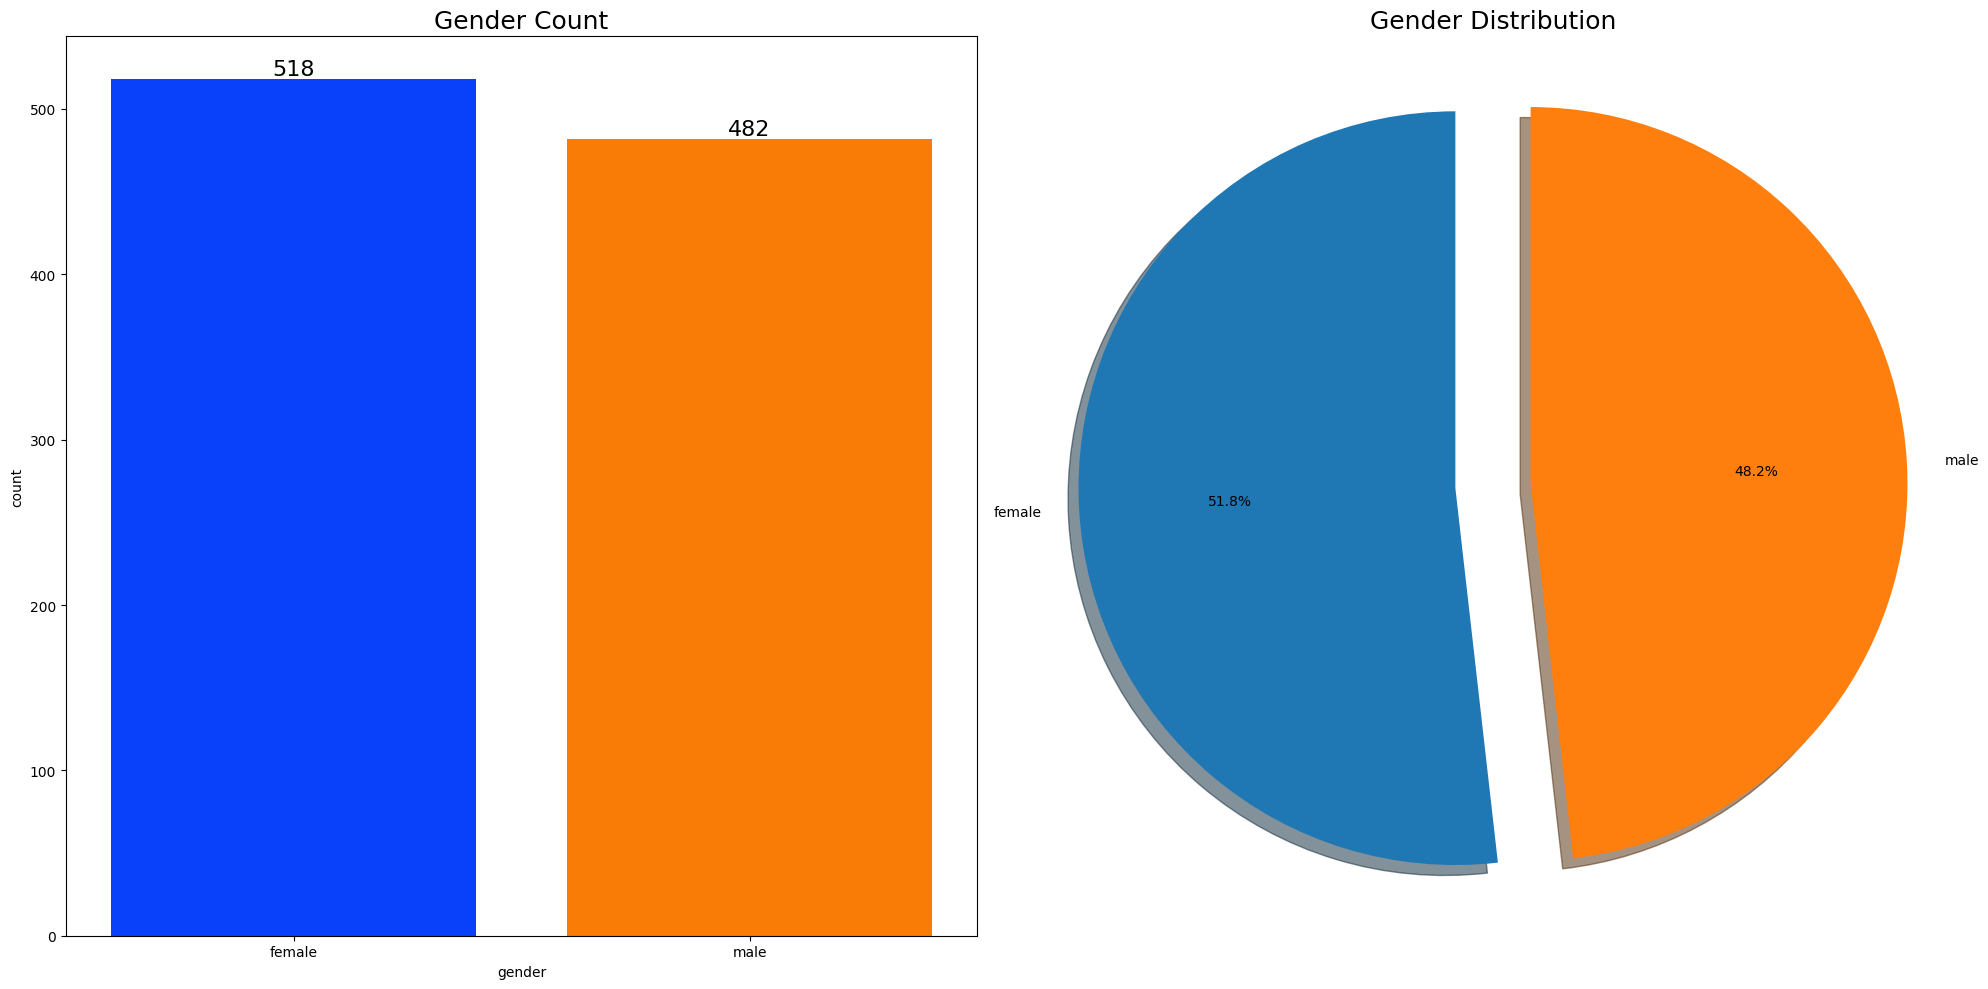

In [ ]:
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
sns.countplot(x='gender', data=df, palette='bright', saturation=0.95)
plt.title('Gender Count', fontsize=18)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, color='black', size=16)

plt.subplot(1,2,2)
sizes = df['gender'].value_counts()
colors = ['#ff8000','#ff4d4d']  
labels = sizes.index.tolist()   
explode = [0.1 if s>0 else 0 for s in sizes]  

plt.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Gender Distribution', fontsize=18)
plt.axis('equal')  
plt.tight_layout()
plt.show()

In [51]:
numeric_cols = df.select_dtypes(include='number').columns

gender_group = df.groupby('gender')[numeric_cols].mean()
gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837303


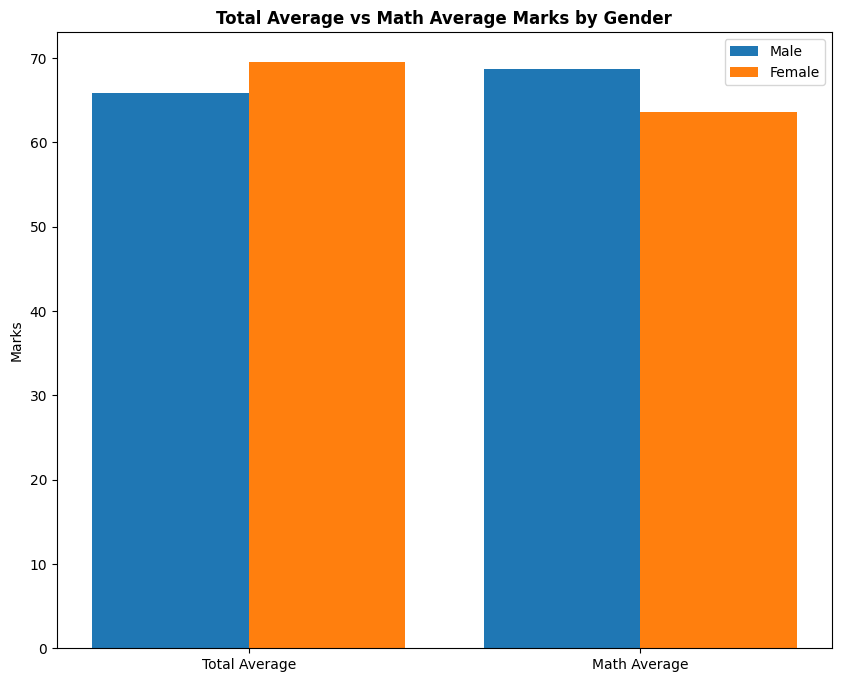

In [52]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']

female_scores = [gender_group.loc['female', 'average_score'], gender_group.loc['female', 'math_score']]
male_scores   = [gender_group.loc['male', 'average_score'], gender_group.loc['male', 'math_score']]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total Average vs Math Average Marks by Gender", fontweight='bold')
plt.legend()
plt.show()

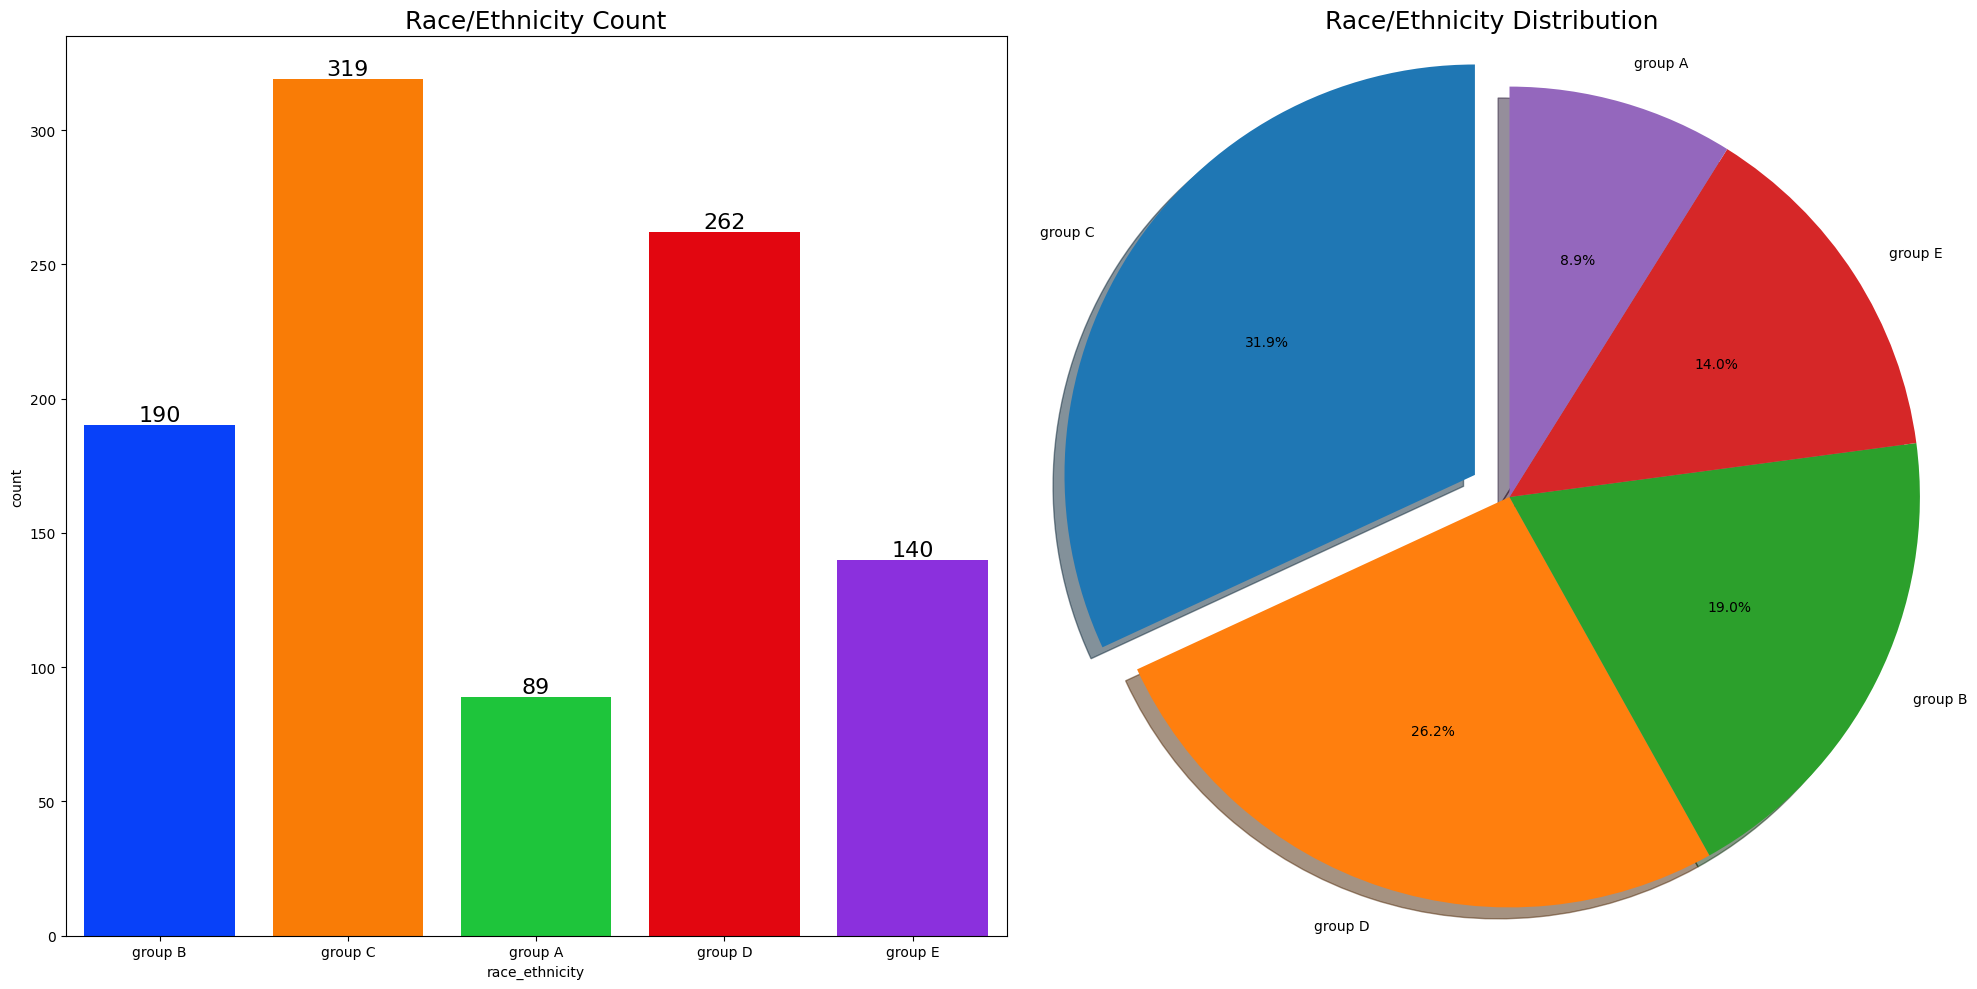

In [59]:
f, ax = plt.subplots(1, 2, figsize=(20,10))

sns.countplot(x='race_ethnicity', data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=16)
ax[0].set_title('Race/Ethnicity Count', fontsize=18)

sizes = df['race_ethnicity'].value_counts()
labels = sizes.index.tolist()
explode = [0.1 if i==0 else 0 for i in range(len(sizes))] 

ax[1].pie(
    sizes,
    labels=labels,
    explode=explode,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
ax[1].set_title('Race/Ethnicity Distribution', fontsize=18)
ax[1].axis('equal') 

plt.tight_layout()
plt.show()

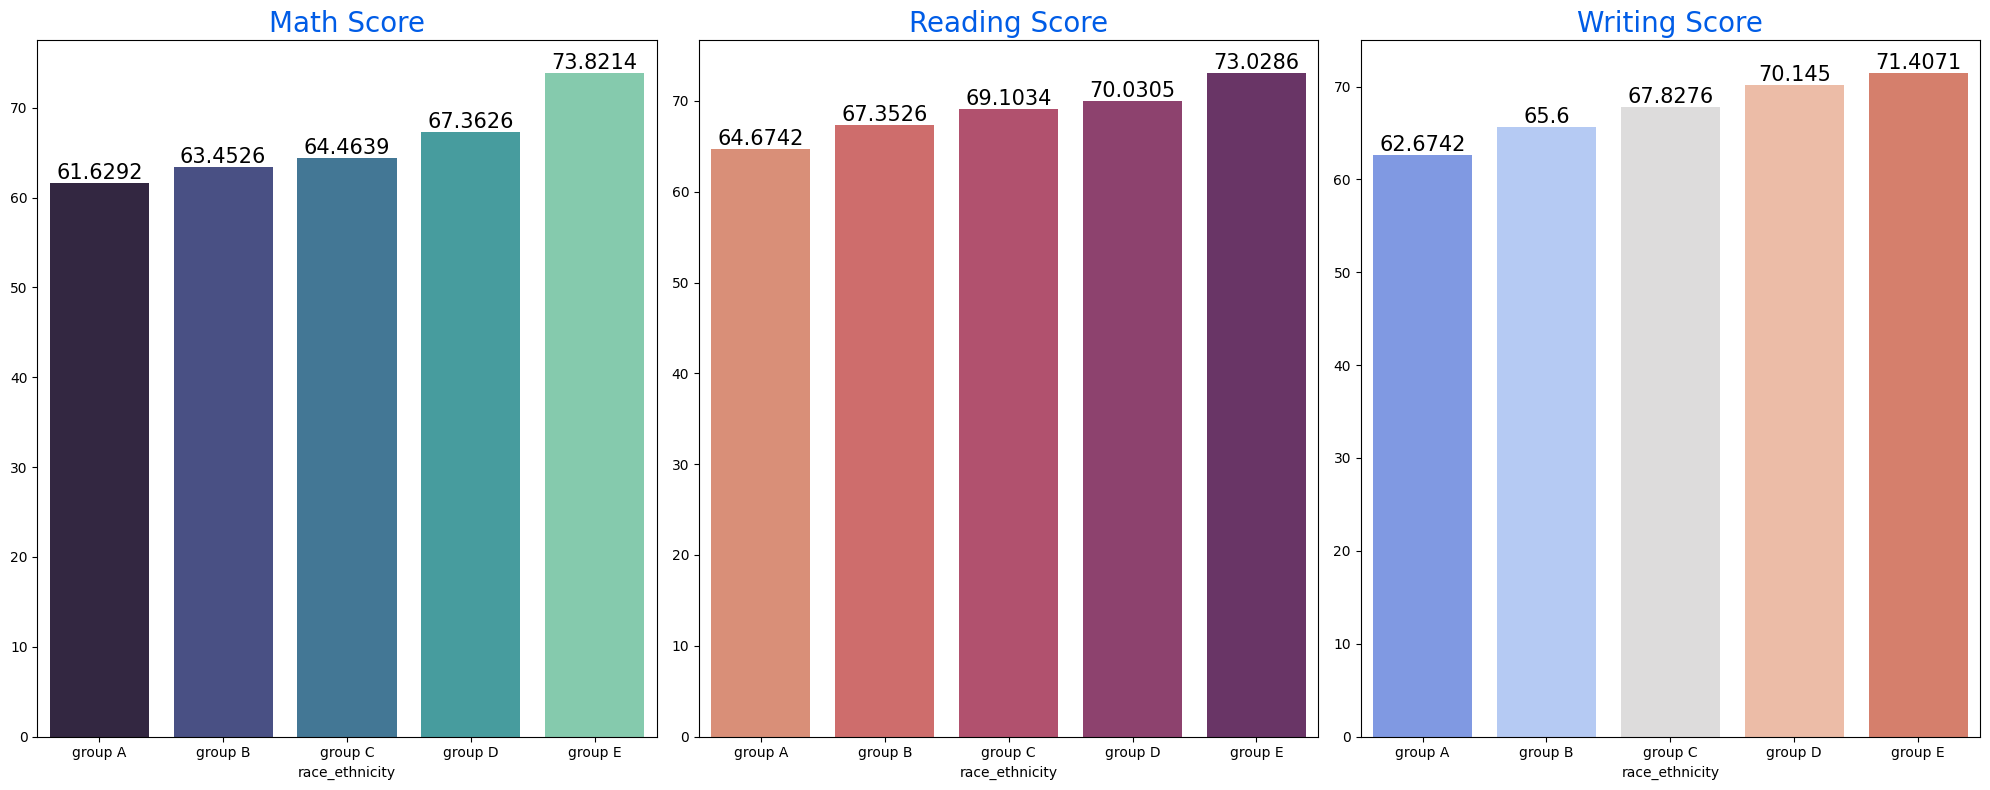

In [ ]:
df.rename(columns=lambda x: x.strip().replace(' ','_').lower(), inplace=True)

group_mean = df.groupby('race_ethnicity')[['math_score','reading_score','writing_score']].mean()

f, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(x=group_mean.index, y=group_mean['math_score'].values, palette='mako', ax=ax[0])
ax[0].set_title('Math Score', color='#005ce6', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

sns.barplot(x=group_mean.index, y=group_mean['reading_score'].values, palette='flare', ax=ax[1])
ax[1].set_title('Reading Score', color='#005ce6', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

sns.barplot(x=group_mean.index, y=group_mean['writing_score'].values, palette='coolwarm', ax=ax[2])
ax[2].set_title('Writing Score', color='#005ce6', size=20)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

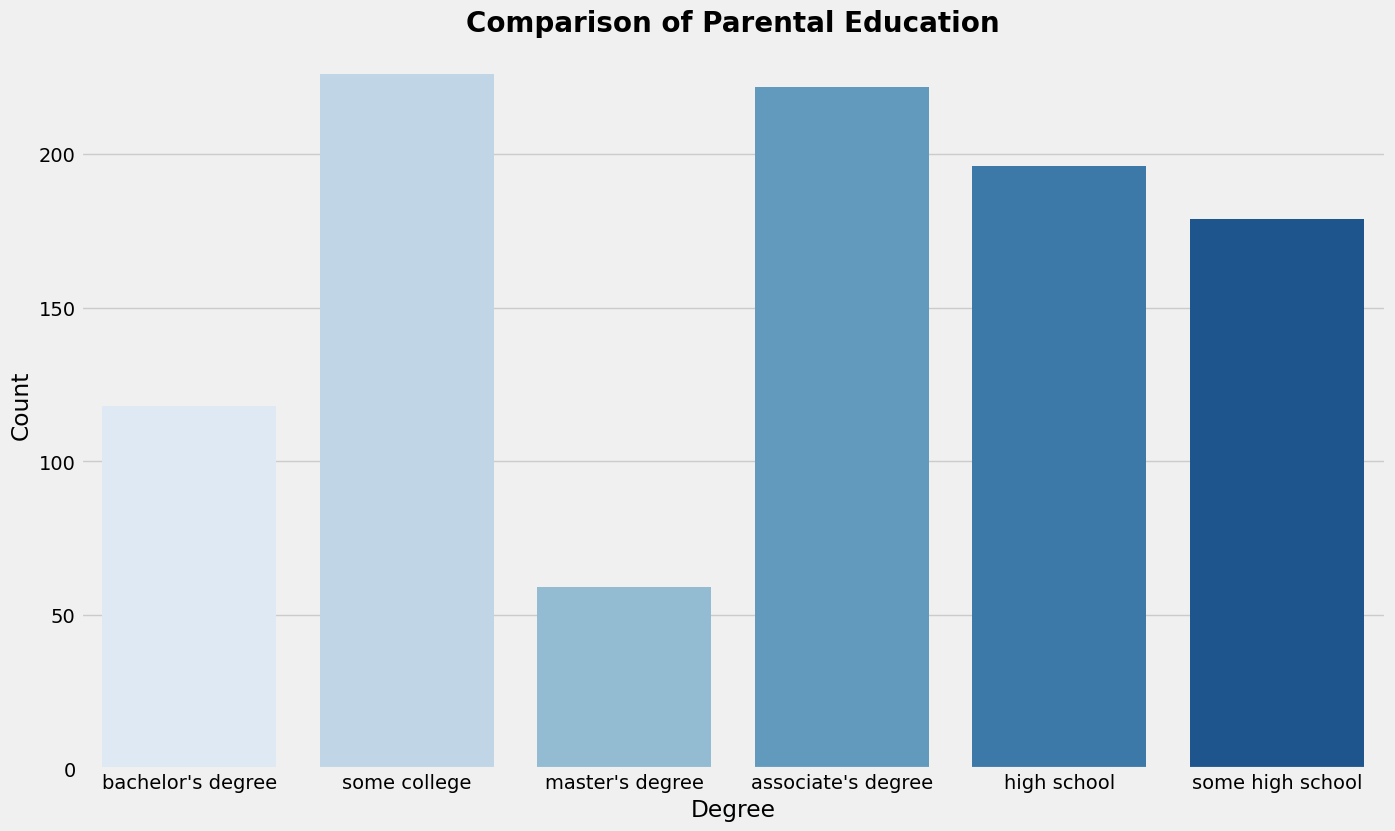

In [65]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

sns.countplot(x='parental_level_of_education', data=df, palette='Blues')
plt.title('Comparison of Parental Education', fontsize=20, fontweight='bold')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

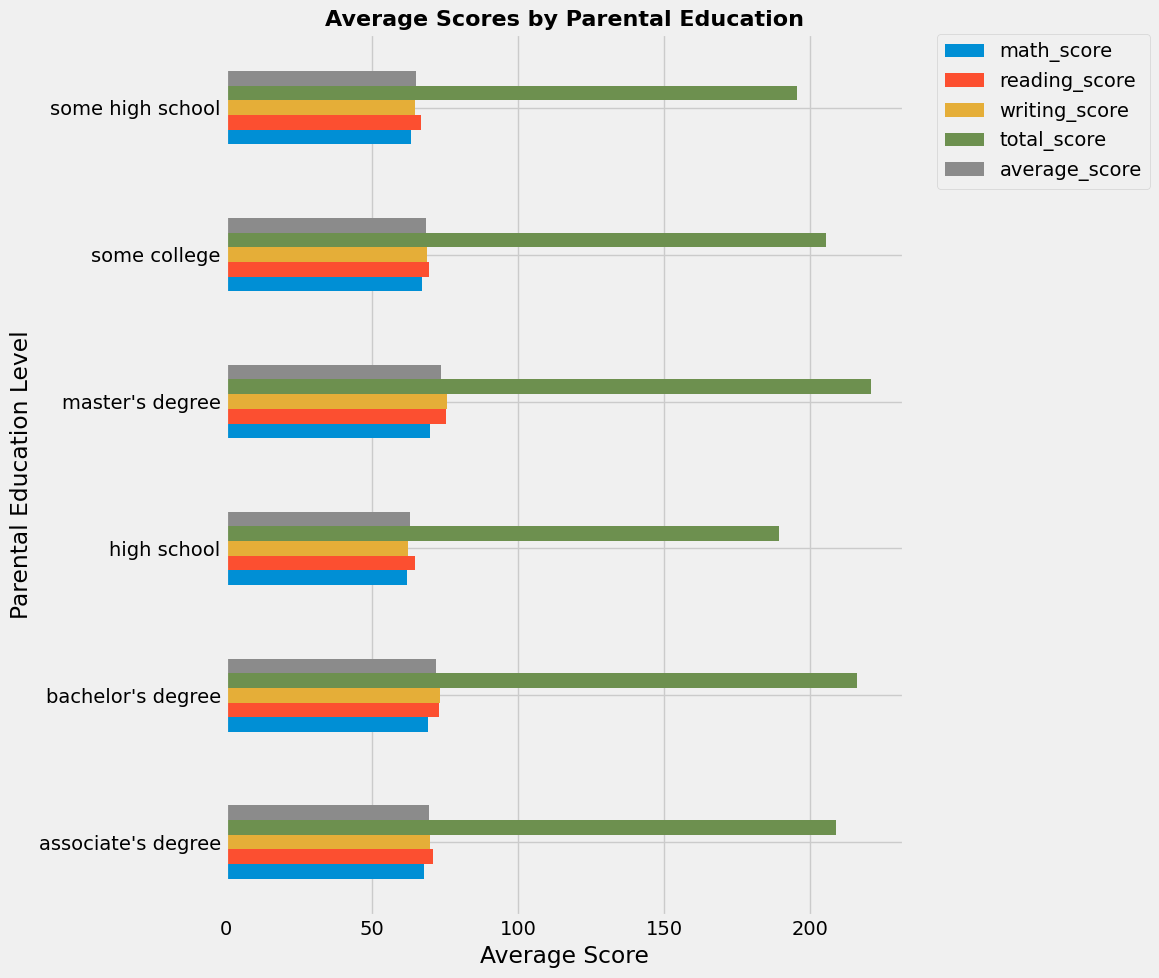

In [68]:
numeric_cols = df.select_dtypes(include='number').columns

parent_mean = df.groupby('parental_level_of_education')[numeric_cols].mean()

parent_mean.plot(kind='barh', figsize=(12,10))

plt.title('Average Scores by Parental Education', fontsize=16, fontweight='bold')
plt.xlabel('Average Score')
plt.ylabel('Parental Education Level')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

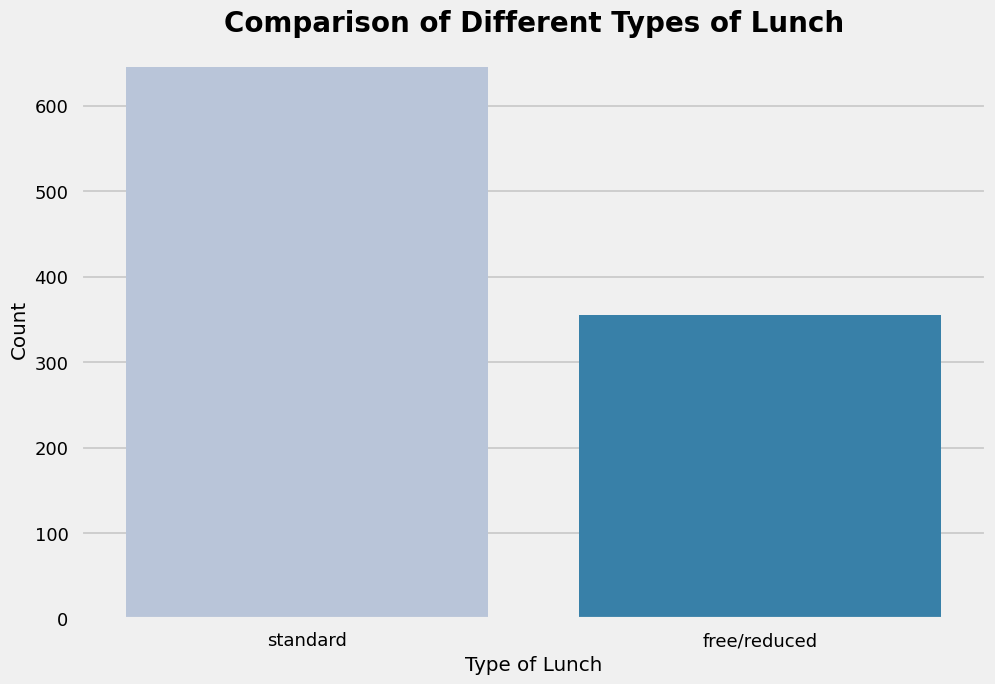

In [75]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')  

sns.countplot(x='lunch', data=df, palette='PuBu')
plt.title('Comparison of Different Types of Lunch', fontsize=20, fontweight='bold')
plt.xlabel('Type of Lunch')
plt.ylabel('Count')
plt.show()

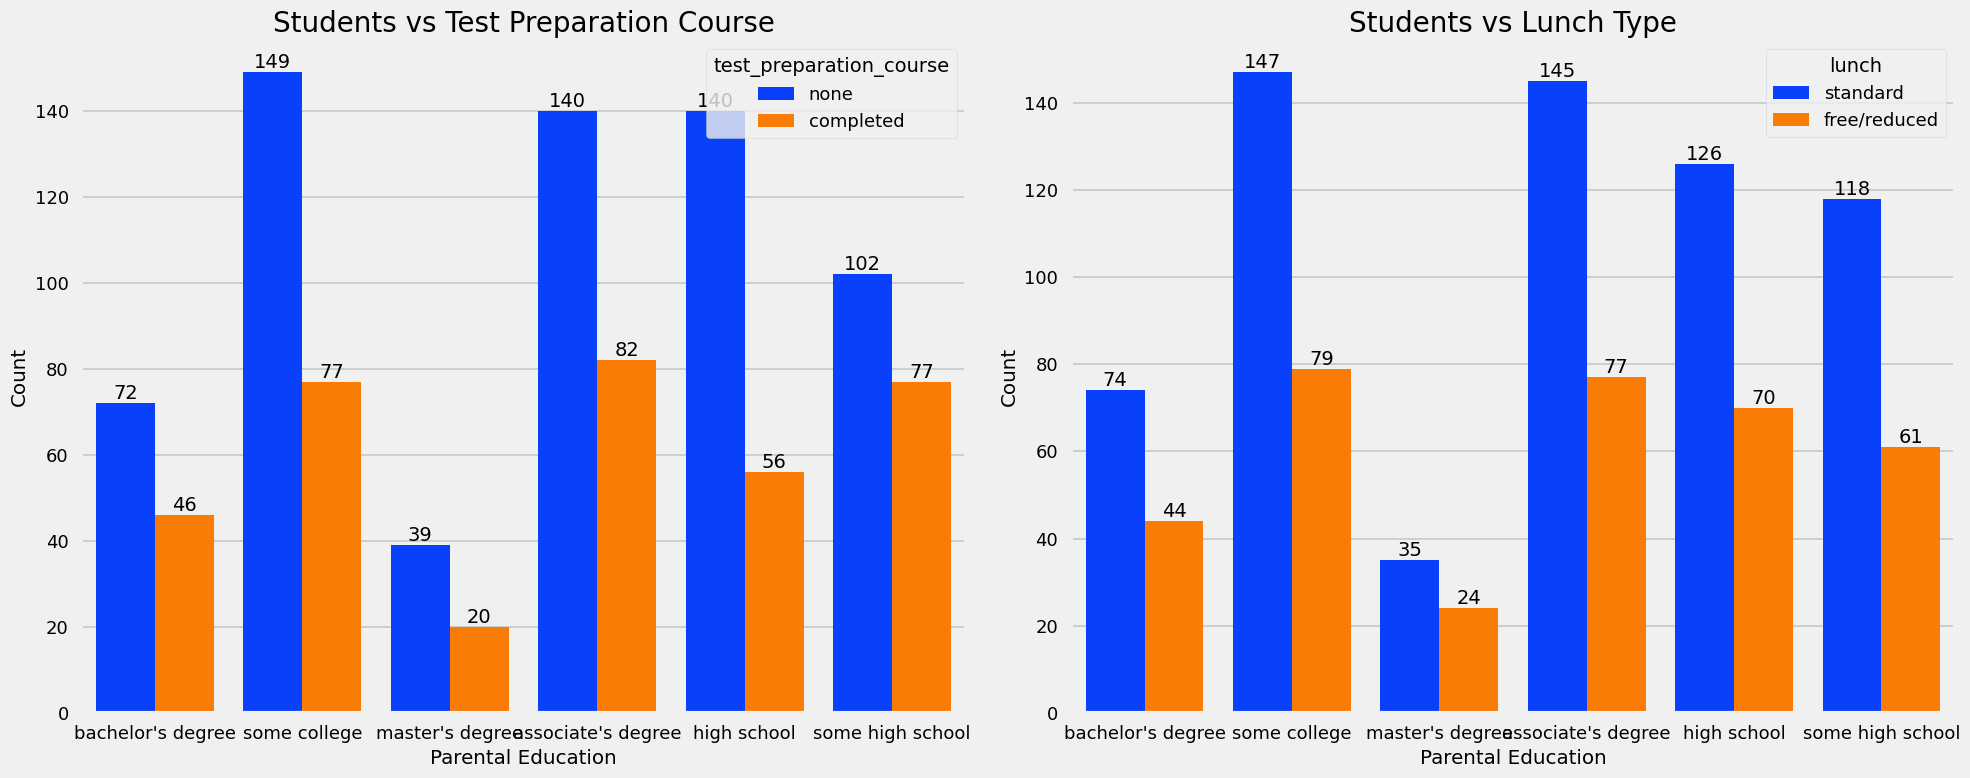

In [79]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='test_preparation_course',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs Test Preparation Course', color='black', fontsize=20)
ax[0].set_xlabel('Parental Education')
ax[0].set_ylabel('Count')
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=14)

sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)
ax[1].set_title('Students vs Lunch Type', color='black', fontsize=20)
ax[1].set_xlabel('Parental Education')
ax[1].set_ylabel('Count')
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=14)

plt.tight_layout()
plt.show()

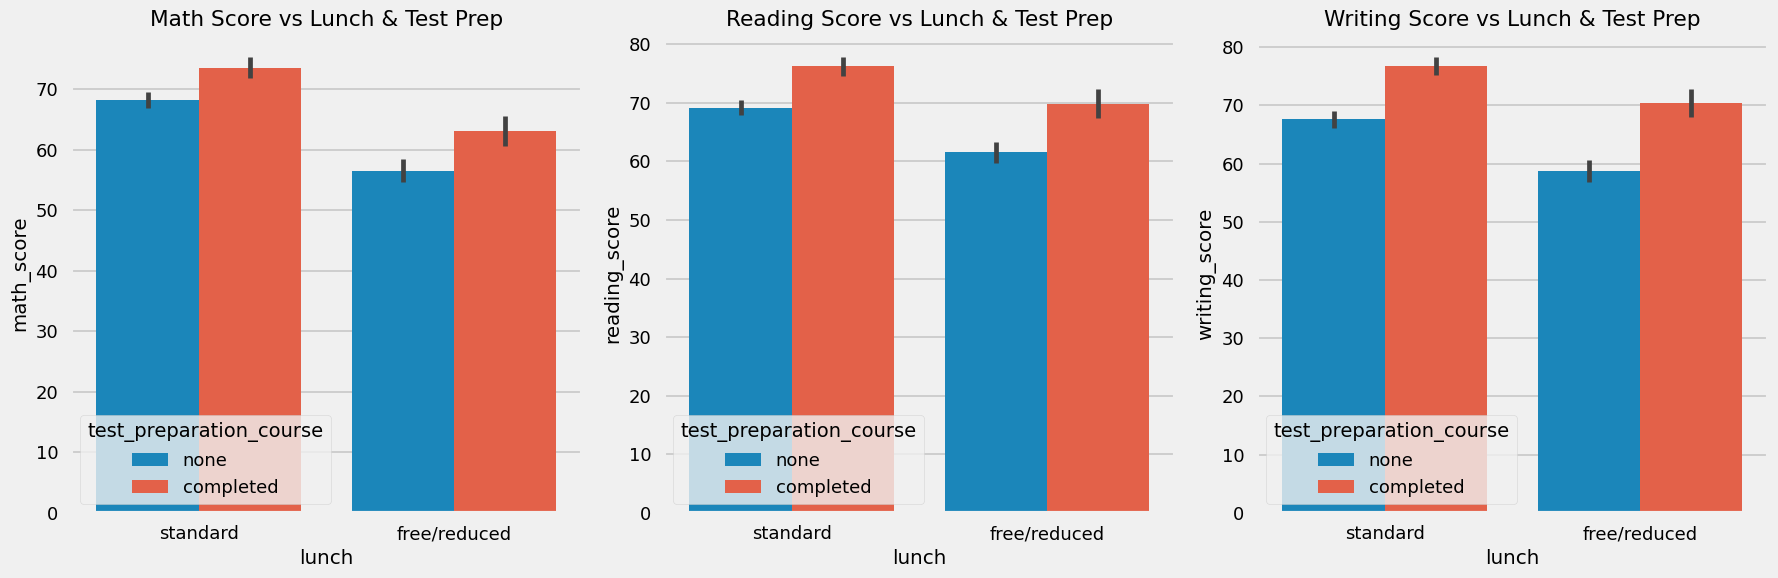

In [80]:
df.rename(columns=lambda x: x.strip().replace(' ','_').lower(), inplace=True)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
sns.barplot(x='lunch', y='math_score', hue='test_preparation_course', data=df)
plt.title('Math Score vs Lunch & Test Prep')

plt.subplot(1,3,2)
sns.barplot(x='lunch', y='reading_score', hue='test_preparation_course', data=df)
plt.title('Reading Score vs Lunch & Test Prep')

plt.subplot(1,3,3)
sns.barplot(x='lunch', y='writing_score', hue='test_preparation_course', data=df)
plt.title('Writing Score vs Lunch & Test Prep')

plt.tight_layout()
plt.show()

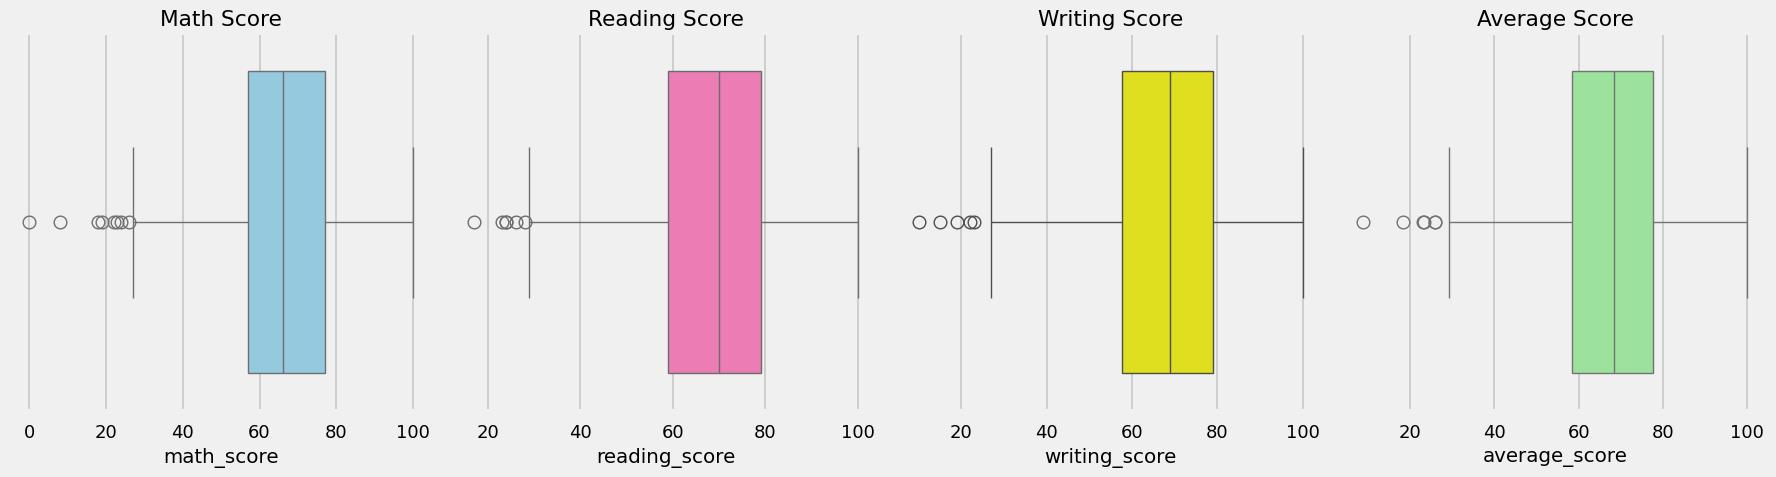

In [82]:
df.rename(columns=lambda x: x.strip().replace(' ','_').lower(), inplace=True)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(x='math_score', data=df, color='skyblue', ax=axes[0])
axes[0].set_title('Math Score')

sns.boxplot(x='reading_score', data=df, color='hotpink', ax=axes[1])
axes[1].set_title('Reading Score')

sns.boxplot(x='writing_score', data=df, color='yellow', ax=axes[2])
axes[2].set_title('Writing Score')

sns.boxplot(x='average_score', data=df, color='lightgreen', ax=axes[3])
axes[3].set_title('Average Score')

plt.tight_layout()
plt.show()

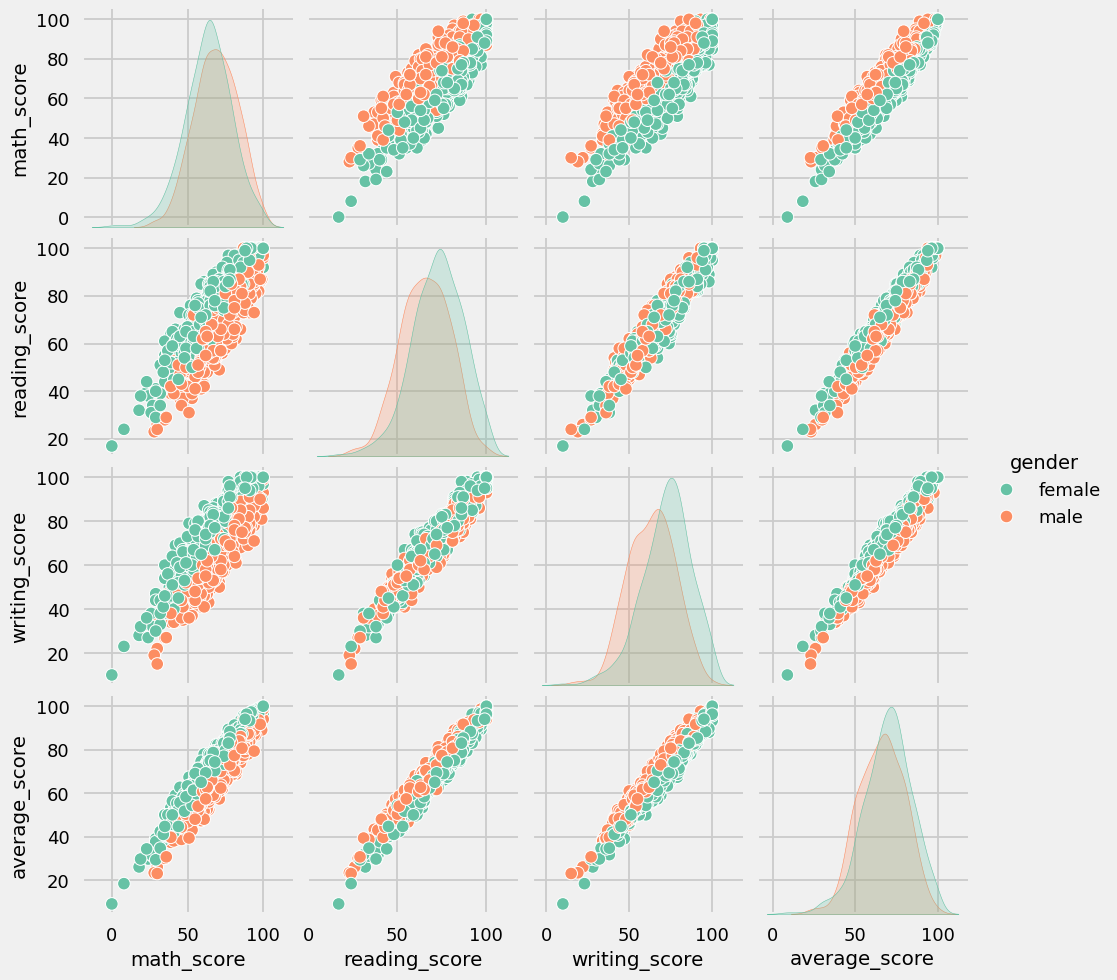

In [83]:
df.rename(columns=lambda x: x.strip().replace(' ','_').lower(), inplace=True)

cols = ['math_score', 'reading_score', 'writing_score', 'average_score']

sns.pairplot(df[cols + ['gender']], hue='gender', palette='Set2')
plt.show()

### 5. Conclusions
- Student's performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's performance is not much related with test preparation course
- Finishing preparation course is benefitial.